Importando as bibliotecas e módulos necessários: 

In [1]:
import os
import pandas as pd
import numpy as np
import sys
import gc

Importando as bases necessárias: 

In [2]:
df_final = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_UNIF.parquet", engine="pyarrow")

In [3]:
df_final_2 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_AED.parquet", engine="pyarrow")

Nessa etapa será feita a definição das variáveis a serem utilizadas:

• Dependente: nível de proficiência em matemática, categorizado;

• Independentes: a definir a partir da análise exploratória e de métricas de importância.
Serão explorados diferentes métodos para realizar essa seleção.

### 1. Categorização do nível de proficiência
Esta seção descreve o processo de categorização inicial a ser adotado: a classificação em 4 classes de proficiência (QEdu), e a divisão em 10 níveis (INEP), sendo eles:

• Insuficiente, para proficiências entre 0-224, Níveis 0 e 1

• Básico, para proficiências entre 225-299, Níveis 2, 3 e 4

• Proficiente, para proficiências entre 300-349, Níveis 5 e 6 

• Avançado, para proficiências a partir de 350, Níveis 7, 8 e 9

In [4]:
bins = [-float('inf'), 200, 225, 250, 275, 300, 325, 350, 375, 400, float('inf')]
labels_numericos = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
labels_proficiencia = [
    'Insuficiente', 
    'Básico',       
    'Proficiente',   
    'Avançado'     
]

In [5]:
#REGIAO, AREA, PUBLICA, LOCALIZACAO, IN_PROFICIENCIA_MT, PROFICIENCIA_MT_SAEB, SEXO, IDADE, COR/RACA, NECESSIDADE ESPECIAL, ESCOLARIDADE MÃE, ESCOLARIDADE PAI, FREQUENCIA LEITURA, FREQUENCIA CONVERSA, FREQUENCIA INCENTIVO ESTUDO, FREQUENCIA INCENIVO TAREFA, FREQUENCIA INCENTIVO AULAS, FREQUENCIA REUNIOES, ASFALTO/CALCAMENTO, AGUA TRATADA, ILUMINAÇAO, TEMPO ATE ESCOLA, LOCOMOCAO ATE ESCOLA, TRANSPORTE OU PASSE, IDADE INTROD ESCOLAR, TIPO ESCOLA, REPROVAÇAO, ABANDONO, TEMPO ESTUDO, TEMPO CURSOS,TEMPO TRAB DOMESTICO, TEMPO TRABALHO FORA, TEMPO LAZER.

### 2. Seleção de características baseada na Análise Exploratória

#### 2019
Colunas selecionadas: LOCALIZACAO, COR/RACA, ESCOL_MAE, FREQUENCIA_CONVERSA, QTD_COMPUTADOR, QTD_CARRO, GARAGEM, IDADE_INTROD_ESC, REPROVACAO, TEMPO_ESTUDO, TEMPO_TRAB_DOMES, POS_EF

In [5]:
df_2019 = df_final[df_final["ANO"] == 2019]

df_2019['NIVEL_PROFICIENCIA'] = pd.cut(df_2019['PROFICIENCIA_SAEB'], bins=bins, labels=labels_numericos, right=False)

nivel_to_proficiencia = {0: 'Insuficiente', 1: 'Insuficiente', 2: 'Básico', 3: 'Básico', 4: 'Básico',
                         5: 'Proficiente', 6: 'Proficiente', 7: 'Avançado', 8: 'Avançado', 9: 'Avançado'}

df_2019['PROFICIENCIA_DESCRICAO'] = df_2019['NIVEL_PROFICIENCIA'].map(nivel_to_proficiencia)

colunas = [
    'LOCALIZACAO', 'COR_RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC',     
    'REPROVACAO', 'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO'

]

df_2019 = df_2019[colunas]
df_2019.head()

,LOCALIZACAO,COR_RACA,ESCOL_MAE,FREQUENCIA_CONVERSA,QTD_COMPUTADOR,QTD_CARRO,GARAGEM,IDADE_INTROD_ESC,REPROVACAO,TEMPO_ESTUDO,TEMPO_TRAB_DOMES,POS_EF,PROFICIENCIA_DESCRICAO
0,1,Branca,Fundamental incompleto,Às vezes,Não respondeu,1 ou 2,Sim,Entre 4 e 7,Sim,Menos de 1 hora,Mais de 2 horas,Estudar e trabalhar,Básico
1,1,Parda,Superior completo,Sempre,0,1 ou 2,Sim,Entre 4 e 7,Não,Menos de 1 hora,Mais de 2 horas,Estudar e trabalhar,Básico
2,1,Parda,Não sabe,Às vezes,0,0,Não,Entre 4 e 7,Não,Entre 1 e 2 horas,Mais de 2 horas,Não sabe,Básico
3,1,Parda,Superior completo,Às vezes,1 ou 2,1 ou 2,Sim,Entre 4 e 7,Não,Entre 1 e 2 horas,Mais de 2 horas,Não sabe,Básico
4,1,Branca,Fundamental incompleto,Nunca,0,1 ou 2,Sim,Entre 4 e 7,Não,Menos de 1 hora,Não respondeu,Estudar e trabalhar,Básico


In [8]:
# Verificando a distribuição das classes 
class_distribution = df_2019['PROFICIENCIA_DESCRICAO'].value_counts()

# Total de registros no dataframe
total_records = len(df_2019)

print("Distribuição de registros:")
for classe, quantidade in class_distribution.items():
    porcentagem = (quantidade / total_records) * 100
    print(f"Classe {classe}: {quantidade} registros ({porcentagem:.2f}%)")

# Verificando se a soma total bate
print(f"\nSoma total de registros: {class_distribution.sum()} (Esperado: {total_records})")


Distribuição de registros:
Classe Básico: 1042352 registros (54.52%)
Classe Insuficiente: 507526 registros (26.55%)
Classe Proficiente: 315123 registros (16.48%)
Classe Avançado: 46930 registros (2.45%)

Soma total de registros: 1911931 (Esperado: 1911931)


#### 2021
Colunas selecionadas: LOCALIZACAO, SEXO, COR/RACA, ESCOL_MAE, FREQUENCIA_CONVERSA, QTD_COMPUTADOR, QTD_CARRO, GARAGEM, IDADE_INTROD_ESC, REPROVACAO, TEMPO_ESTUDO, TEMPO_TRAB_DOMES, POS_EF

In [19]:
df_2021 = df_final_2[df_final_2["ANO"] == 2021]

df_2021['NIVEL_PROFICIENCIA'] = pd.cut(df_2021['PROFICIENCIA_SAEB'], bins=bins, labels=labels_numericos, right=False)

nivel_to_proficiencia = {0: 'Insuficiente', 1: 'Insuficiente', 2: 'Básico', 3: 'Básico', 4: 'Básico',
                         5: 'Proficiente', 6: 'Proficiente', 7: 'Avançado', 8: 'Avançado', 9: 'Avançado'}

df_2021['PROFICIENCIA_DESCRICAO'] = df_2021['NIVEL_PROFICIENCIA'].map(nivel_to_proficiencia)

colunas = [
    'LOCALIZACAO', 'SEXO', 'COR/RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC',     
    'REPROVACAO', 'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO'

]

df_2021 = df_2021[colunas]
df_2021.head()

,LOCALIZACAO,SEXO,COR/RACA,ESCOL_MAE,FREQUENCIA_CONVERSA,QTD_COMPUTADOR,QTD_CARRO,GARAGEM,IDADE_INTROD_ESC,REPROVACAO,TEMPO_ESTUDO,TEMPO_TRAB_DOMES,POS_EF,PROFICIENCIA_DESCRICAO
0,1,Masculino,Branca,Médio completo,Às vezes,0,0,Sim,3 ou menos,Não,Entre 1 e 2 horas,Mais de 2 horas,Estudar e trabalhar,Básico
1,1,Masculino,Parda,Não sabe,Sempre,1 ou 2,0,Não,Entre 4 e 7,Sim,Menos de 1 hora,Mais de 2 horas,Somente trabalhar,Insuficiente
2,1,Feminino,Branca,Fundamental incompleto,Às vezes,1 ou 2,Não respondeu,Sim,Entre 4 e 7,Não respondeu,Menos de 1 hora,Não usa o tempo para isso,Estudar e trabalhar,Insuficiente
3,1,Feminino,Parda,Não sabe,Nunca,0,1 ou 2,Não,Entre 4 e 7,Sim,Entre 1 e 2 horas,Menos de 1 hora,Estudar e trabalhar,Insuficiente
4,1,Feminino,Outra,Não sabe,Às vezes,0,0,Não,Entre 4 e 7,Não,Menos de 1 hora,Entre 1 e 2 horas,Estudar e trabalhar,Básico


In [10]:
# Verificando a distribuição das classes 
class_distribution = df_2021['PROFICIENCIA_DESCRICAO'].value_counts()

# Total de registros no dataframe
total_records = len(df_2021)

print("Distribuição de registros:")
for classe, quantidade in class_distribution.items():
    porcentagem = (quantidade / total_records) * 100
    print(f"Classe {classe}: {quantidade} registros ({porcentagem:.2f}%)")

# Verificando se a soma total bate
print(f"\nSoma total de registros: {class_distribution.sum()} (Esperado: {total_records})")


Distribuição de registros:
Classe Básico: 1016280 registros (53.88%)
Classe Insuficiente: 569072 registros (30.17%)
Classe Proficiente: 270061 registros (14.32%)
Classe Avançado: 30766 registros (1.63%)

Soma total de registros: 1886179 (Esperado: 1886179)


#### 2023
Colunas selecionadas: LOCALIZACAO, SEXO, COR/RACA, ESCOL_MAE, FREQUENCIA_CONVERSA, QTD_COMPUTADOR, QTD_CARRO, GARAGEM, IDADE_INTROD_ESC, REPROVACAO, TEMPO_ESTUDO, TEMPO_TRAB_DOMES, POS_EF

In [25]:
df_2023 = df_final_2[df_final_2["ANO"] == 2023]

df_2023['NIVEL_PROFICIENCIA'] = pd.cut(df_2023['PROFICIENCIA_SAEB'], bins=bins, labels=labels_numericos, right=False)

nivel_to_proficiencia = {0: 'Insuficiente', 1: 'Insuficiente', 2: 'Básico', 3: 'Básico', 4: 'Básico',
                         5: 'Proficiente', 6: 'Proficiente', 7: 'Avançado', 8: 'Avançado', 9: 'Avançado'}

df_2023['PROFICIENCIA_DESCRICAO'] = df_2023['NIVEL_PROFICIENCIA'].map(nivel_to_proficiencia)

colunas = [
    'LOCALIZACAO', 'SEXO', 'COR/RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC',     
    'REPROVACAO', 'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO'

]

df_2023 = df_2023[colunas]
df_2023.head()

,LOCALIZACAO,SEXO,COR/RACA,ESCOL_MAE,FREQUENCIA_CONVERSA,QTD_COMPUTADOR,QTD_CARRO,GARAGEM,IDADE_INTROD_ESC,REPROVACAO,TEMPO_ESTUDO,TEMPO_TRAB_DOMES,POS_EF,PROFICIENCIA_DESCRICAO
1886179,1,Masculino,Parda,Médio completo,Às vezes,1 ou 2,1 ou 2,Sim,Entre 4 e 7,Não,Não usa o tempo para isso,Mais de 2 horas,Somente trabalhar,Insuficiente
1886180,1,Feminino,Preta,Não sabe,Não respondeu,Não respondeu,Não respondeu,Não respondeu,Entre 4 e 7,Não,Não respondeu,Não respondeu,Somente estudar,Insuficiente
1886181,1,Feminino,Parda,Fundamental incompleto,Não respondeu,0,1 ou 2,Não,Entre 4 e 7,Sim,Menos de 1 hora,Mais de 2 horas,Somente estudar,Básico
1886182,1,Masculino,Não respondeu,Fundamental incompleto,Nunca,1 ou 2,1 ou 2,Não,Entre 4 e 7,Sim,Menos de 1 hora,Entre 1 e 2 horas,Estudar e trabalhar,Básico
1886183,1,Feminino,Parda,Médio completo,Sempre,1 ou 2,1 ou 2,Sim,Entre 4 e 7,Não,Menos de 1 hora,Mais de 2 horas,Estudar e trabalhar,Básico


In [12]:
# Verificando a distribuição das classes 
class_distribution = df_2023['PROFICIENCIA_DESCRICAO'].value_counts()

# Total de registros no dataframe
total_records = len(df_2023)

print("Distribuição de registros:")
for classe, quantidade in class_distribution.items():
    porcentagem = (quantidade / total_records) * 100
    print(f"Classe {classe}: {quantidade} registros ({porcentagem:.2f}%)")

# Verificando se a soma total bate
print(f"\nSoma total de registros: {class_distribution.sum()} (Esperado: {total_records})")


Distribuição de registros:
Classe Básico: 1052094 registros (51.26%)
Classe Insuficiente: 655152 registros (31.92%)
Classe Proficiente: 294108 registros (14.33%)
Classe Avançado: 51302 registros (2.50%)

Soma total de registros: 2052656 (Esperado: 2052656)


--------------------------- Modelagem Preditiva ----------------------------
#### 2019

In [20]:
#!pip install seaborn
#!pip install scipy
#!pip install statsmodels scikit-learn

In [14]:
#import pandas as pd
#import numpy as np
import scipy.stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Ajustando a variável alvo
df_2019['PROFICIENCIA_DESCRICAO'] = df_2019['PROFICIENCIA_DESCRICAO'].replace({
    'Básico': 'Insuficiente',
    'Insuficiente': 'Insuficiente',
    'Proficiente': 'Proficiente',
    'Avançado': 'Proficiente'
})

# Variável dependente
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2019.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Cria dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove valores ausentes
X = X.dropna()

# Ajusta y ao mesmo índice
y = y.loc[X.index]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Adiciona intercepto
X = sm.add_constant(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
log_reg = sm.Logit(y_train, X_train).fit()

print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.437510
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     PROFICIENCIA_DESCRICAO   No. Observations:              1529544
Model:                              Logit   Df Residuals:                  1529504
Method:                               MLE   Df Model:                           39
Date:                    Wed, 27 May 2026   Pseudo R-squ.:                 0.09797
Time:                            22:41:49   Log-Likelihood:            -6.6919e+05
converged:                           True   LL-Null:                   -7.4187e+05
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const       


Coeficientes, Odds Ratios e p-values do Modelo:
                                       Feature  Coefficient  Odds Ratio  \
2                               SEXO_Masculino     0.626337    1.870746   
4                           SEXO_Não respondeu     0.604319    1.830005   
19                    QTD_COMPUTADOR_3 ou mais     0.504289    1.655808   
14                 ESCOL_MAE_Superior completo     0.353319    1.423785   
18                       QTD_COMPUTADOR_1 ou 2     0.325491    1.384711   
3                       SEXO_Não quis declarar     0.283505    1.327775   
41                      POS_EF_Somente estudar     0.250879    1.285155   
11                    ESCOL_MAE_Médio completo     0.224677    1.251918   
24                       GARAGEM_Não respondeu     0.215420    1.240383   
21                            QTD_CARRO_1 ou 2     0.191992    1.211661   
28              IDADE_INTROD_ESC_Não respondeu     0.152471    1.164709   
31                TEMPO_ESTUDO_Mais de 2 horas     

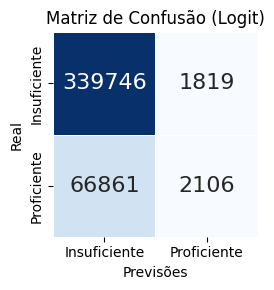

In [30]:
# Extraindo os coeficientes, odds ratios e p-values
coefficients = log_reg.params
odds_ratios = np.exp(coefficients)  # Odds ratios calculados como exp(coeficiente)
p_values = log_reg.pvalues

# Apresentando os resultados em um DataFrame
results = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
}).sort_values(by='Odds Ratio', ascending=False)

print("\nCoeficientes, Odds Ratios e p-values do Modelo:")
print(results)

# Previsões no conjunto de teste
y_pred = (log_reg.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão com os nomes das classes
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)

# Adicionando título e rótulos
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logit)")
plt.tight_layout()
plt.show()

#### 2021

In [34]:
# Ajustando a variável alvo
df_2021['PROFICIENCIA_DESCRICAO'] = df_2021['PROFICIENCIA_DESCRICAO'].replace({
    'Básico': 'Insuficiente',
    'Insuficiente': 'Insuficiente',
    'Proficiente': 'Proficiente',
    'Avançado': 'Proficiente'
})

# Variável dependente
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2021.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Cria dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove valores ausentes
X = X.dropna()

# Ajusta y ao mesmo índice
y = y.loc[X.index]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Adiciona intercepto
X = sm.add_constant(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
log_reg = sm.Logit(y_train, X_train).fit()

print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.388532
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     PROFICIENCIA_DESCRICAO   No. Observations:              1508943
Model:                              Logit   Df Residuals:                  1508901
Method:                               MLE   Df Model:                           41
Date:                    Fri, 29 May 2026   Pseudo R-squ.:                  0.1143
Time:                            15:02:17   Log-Likelihood:            -5.8627e+05
converged:                           True   LL-Null:                   -6.6192e+05
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const       


Coeficientes, Odds Ratios e p-values do Modelo:
                                       Feature  Coefficient  Odds Ratio  \
2                               SEXO_Masculino     0.639736    1.895981   
18                    QTD_COMPUTADOR_3 ou mais     0.513233    1.670684   
17                       QTD_COMPUTADOR_1 ou 2     0.372205    1.450931   
13                 ESCOL_MAE_Superior completo     0.345678    1.412948   
3                           SEXO_Não respondeu     0.269723    1.309602   
40                      POS_EF_Somente estudar     0.212846    1.237195   
10                    ESCOL_MAE_Médio completo     0.207439    1.230522   
20                            QTD_CARRO_1 ou 2     0.206634    1.229533   
27              IDADE_INTROD_ESC_Não respondeu     0.201284    1.222972   
23                       GARAGEM_Não respondeu     0.193045    1.212937   
24                                 GARAGEM_Sim     0.112312    1.118862   
28                    REPROVACAO_Não respondeu     

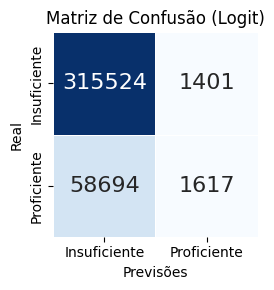

In [39]:
# Extraindo os coeficientes, odds ratios e p-values
coefficients = log_reg.params
odds_ratios = np.exp(coefficients)  # Odds ratios calculados como exp(coeficiente)
p_values = log_reg.pvalues

# Apresentando os resultados em um DataFrame
results = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
}).sort_values(by='Odds Ratio', ascending=False)

print("\nCoeficientes, Odds Ratios e p-values do Modelo:")
print(results)

# Previsões no conjunto de teste
y_pred = (log_reg.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão com os nomes das classes
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)

# Adicionando título e rótulos
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logit)")
plt.tight_layout()
plt.show()

#### 2023

In [27]:
# Ajustando a variável alvo
df_2023['PROFICIENCIA_DESCRICAO'] = df_2023['PROFICIENCIA_DESCRICAO'].replace({
    'Básico': 'Insuficiente',
    'Insuficiente': 'Insuficiente',
    'Proficiente': 'Proficiente',
    'Avançado': 'Proficiente'
})

# Variável dependente
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2023.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Cria dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove valores ausentes
X = X.dropna()

# Ajusta y ao mesmo índice
y = y.loc[X.index]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Adiciona intercepto
X = sm.add_constant(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
log_reg = sm.Logit(y_train, X_train).fit()

print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.406694
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     PROFICIENCIA_DESCRICAO   No. Observations:              1642124
Model:                              Logit   Df Residuals:                  1642081
Method:                               MLE   Df Model:                           42
Date:                    Wed, 27 May 2026   Pseudo R-squ.:                  0.1027
Time:                            22:49:16   Log-Likelihood:            -6.6784e+05
converged:                           True   LL-Null:                   -7.4430e+05
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const       


Coeficientes, Odds Ratios e p-values do Modelo:
                                       Feature  Coefficient  Odds Ratio  \
2                               SEXO_Masculino     0.639736    1.895981   
18                    QTD_COMPUTADOR_3 ou mais     0.513233    1.670684   
17                       QTD_COMPUTADOR_1 ou 2     0.372205    1.450931   
13                 ESCOL_MAE_Superior completo     0.345678    1.412948   
3                           SEXO_Não respondeu     0.269723    1.309602   
40                      POS_EF_Somente estudar     0.212846    1.237195   
10                    ESCOL_MAE_Médio completo     0.207439    1.230522   
20                            QTD_CARRO_1 ou 2     0.206634    1.229533   
27              IDADE_INTROD_ESC_Não respondeu     0.201284    1.222972   
23                       GARAGEM_Não respondeu     0.193045    1.212937   
24                                 GARAGEM_Sim     0.112312    1.118862   
28                    REPROVACAO_Não respondeu     

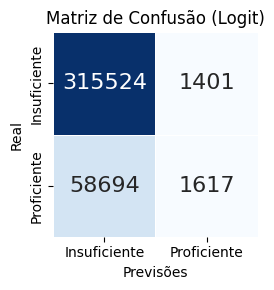

In [40]:
# Extraindo os coeficientes, odds ratios e p-values
coefficients = log_reg.params
odds_ratios = np.exp(coefficients)  # Odds ratios calculados como exp(coeficiente)
p_values = log_reg.pvalues

# Apresentando os resultados em um DataFrame
results = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
}).sort_values(by='Odds Ratio', ascending=False)

print("\nCoeficientes, Odds Ratios e p-values do Modelo:")
print(results)

# Previsões no conjunto de teste
y_pred = (log_reg.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão com os nomes das classes
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)

# Adicionando título e rótulos
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logit)")
plt.tight_layout()
plt.show()